In [19]:
from ultralytics import YOLO
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.spatial import cKDTree
import cv2
import networkx as nx

device = "cuda" if torch.cuda.is_available() else "cpu" 
device

'cuda'

In [9]:
model_seg = YOLO("model/model_seg.pt")

In [40]:
def get_mask(img_path, out_size=(512,288)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_copy = cv2.resize(img.copy(), out_size)

    h, w = img.shape[:2]
    road = model_seg.predict(
        source=img_path,
        device=device,
        save=False,
        show=False
    )

    # lấy mask đầu tiên (lane/road tùy model bạn đang có)
    mask = road[0].masks.data[0].cpu().numpy()  # (H, W)

    # resize + threshold -> 2D 0/1
    mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    mask_bin = (mask_resized > 0.5).astype(np.uint8)  # (288,512)

    return img_copy, mask_bin

def draw(frame, mask, centroid = None):
    sk = skeletonize(lane_mask)

    # Dựng đồ thị từ skeleton
    G = nx.Graph()
    h, w = sk.shape
    for y in range(h):
        for x in range(w):
            if not sk[y,x]:
                continue
            for dy in [-1,0,1]:
                for dx in [-1,0,1]:
                    if dy==0 and dx==0:
                        continue
                    ny, nxp = y+dy, x+dx
                    if 0<=ny<h and 0<=nxp<w and sk[ny,nxp]:
                        G.add_edge((y,x),(ny,nxp))

    # Tách nhánh (connected components)
    branches = [list(G.subgraph(c).nodes) for c in nx.connected_components(G)]

    # Chọn nhánh chính (dài nhất)
    main_branch = max(branches, key=len)
    axis_pts = [(p[1], p[0]) for p in main_branch]  # (x,y) format
    axis_pts = np.array(axis_pts, dtype=np.float32)

    # Vẽ skeleton (axis) lên ảnh
    for (x, y) in axis_pts:
        cv2.circle(frame, (int(x), int(y)), 1, (0,0,0), -1)

    # KDTree để tính tangent local
    tree = cKDTree(axis_pts)

    def get_local_tangent(pt, k=6):
        _, idx = tree.query(pt)
        i1 = max(0, idx-k)
        i2 = min(len(axis_pts)-1, idx+k)
        v = axis_pts[i2] - axis_pts[i1]
        return v / (np.linalg.norm(v) + 1e-6)

    # --- Điểm cần tính hướng ---
    centroid = centroid if centroid else (300, 150)
    tangent = get_local_tangent(centroid)

    # Vẽ vector local direction
    def draw_vector(img, origin, vec, scale=40):
        end = (int(origin[0] + vec[0]*scale), int(origin[1] + vec[1]*scale))
        cv2.arrowedLine(img, origin, end, (0,0,255), 2)

    draw_vector(frame, centroid, tangent)

    # Hiển thị kết quả
    plt.imshow(frame)

image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_9_cam_1_38.png: 384x640 1 Lane, 164.0ms
Speed: 3.7ms preprocess, 164.0ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)


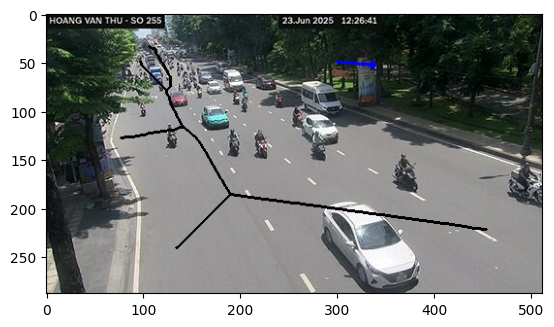

In [53]:
# img_path = r"tmp\test-image\test3.jpg"
img_path = r"data\detection-task\images\train\Duong_9_cam_1_38.png"

img, lane_mask = get_mask(img_path)

draw(img, lane_mask, (300, 50))